In [ ]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)

subset = X[["alcohol", "magnesium"]]
y = data.target 





[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    subset, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter = 500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)


[0 0 2 0 1 0 1 0 1 2 2 0 2 1 0 1 1 1 0 1 0 2 1 0 1 0 1 1 1 0 0 1 2 0 0 0 0
 1 1 2 2 1 1 0 2 2 1 1 1 0 2 0 2 2]


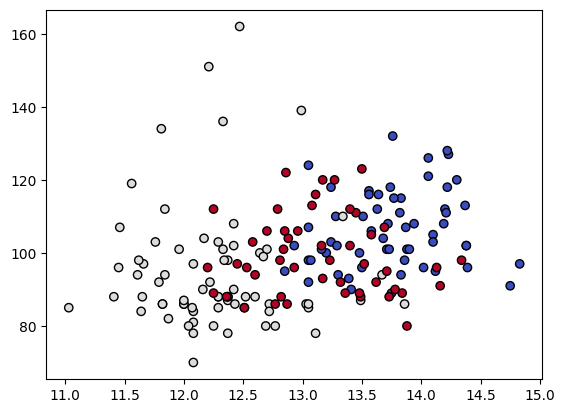

In [4]:
scatter = plt.scatter(X["alcohol"], X["magnesium"], c=y, cmap='coolwarm', edgecolors='k')


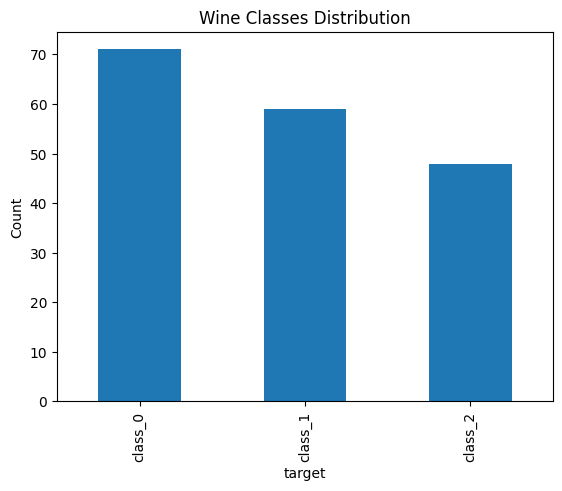

In [24]:
import matplotlib.pyplot as plt

X["target"] = data.target
X["target"].value_counts().plot(kind="bar")
plt.xticks([0,1,2], data.target_names)
plt.title("Wine Classes Distribution")
plt.ylabel("Count")
plt.show()


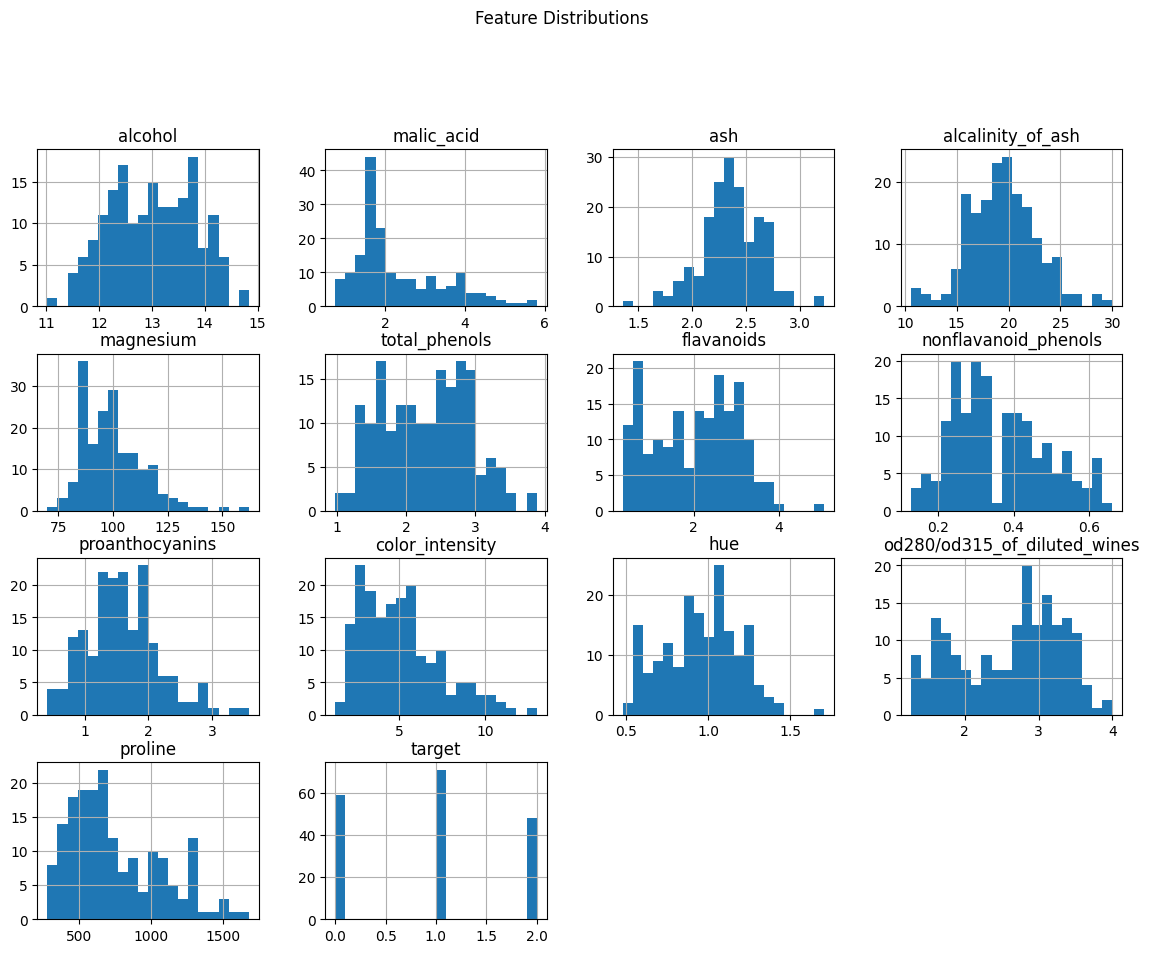

In [25]:
X.hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.show()


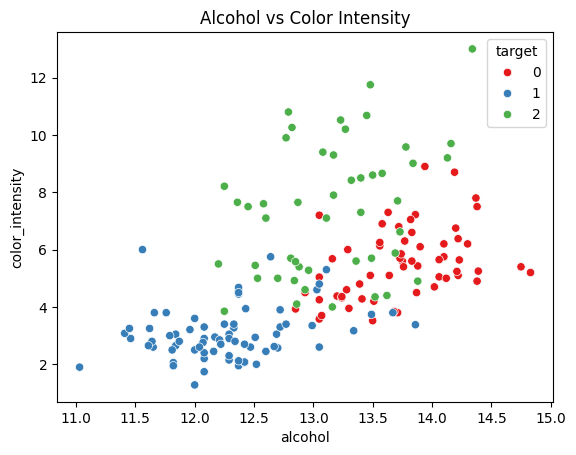

In [27]:
import seaborn as sns

sns.scatterplot(data=X, x="alcohol", y="color_intensity", hue="target", palette="Set1")
plt.title("Alcohol vs Color Intensity")
plt.show()


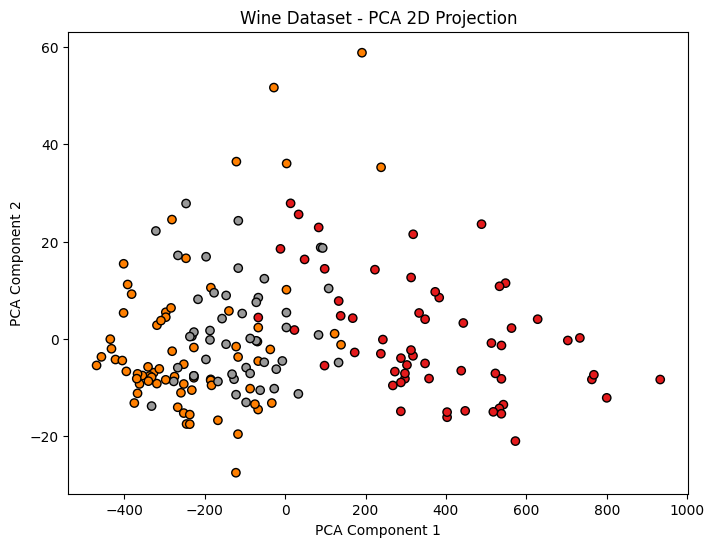

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X[data.feature_names])

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=X["target"], cmap="Set1", edgecolors="k")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Wine Dataset - PCA 2D Projection")
plt.show()


In [39]:
from sklearn.model_selection import train_test_split

subset = X[["alcohol", "magnesium"]]

X_train, X_test, y_train, y_test = train_test_split(
    subset, y, test_size=0.3, random_state=42
)

In [40]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [42]:
from sklearn import tree

text_tree = tree.export_text(model, feature_names=list(subset.columns))
print(text_tree)


|--- alcohol <= 12.76
|   |--- alcohol <= 12.18
|   |   |--- class: 1
|   |--- alcohol >  12.18
|   |   |--- alcohol <= 12.27
|   |   |   |--- magnesium <= 84.50
|   |   |   |   |--- class: 1
|   |   |   |--- magnesium >  84.50
|   |   |   |   |--- magnesium <= 131.50
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- magnesium >  131.50
|   |   |   |   |   |--- class: 1
|   |   |--- alcohol >  12.27
|   |   |   |--- alcohol <= 12.35
|   |   |   |   |--- class: 1
|   |   |   |--- alcohol >  12.35
|   |   |   |   |--- alcohol <= 12.36
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- alcohol >  12.36
|   |   |   |   |   |--- magnesium <= 92.00
|   |   |   |   |   |   |--- magnesium <= 85.50
|   |   |   |   |   |   |   |--- magnesium <= 84.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- magnesium >  84.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- magnesium >  85.50
|   |   |   |   |   |   |   |--- class: 1
|   | 

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


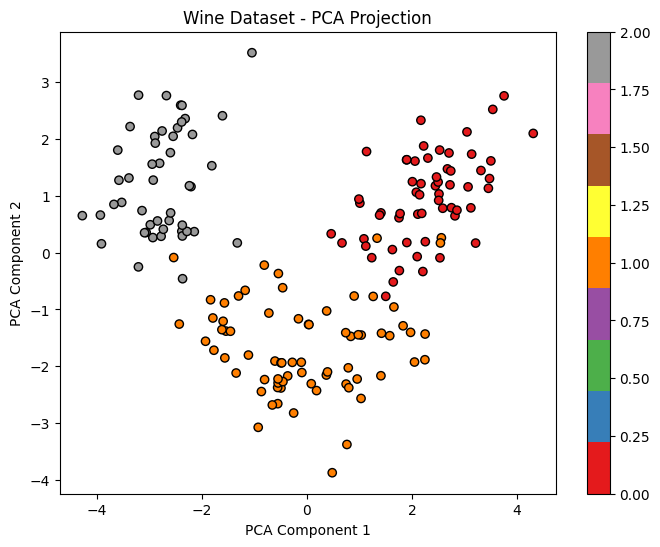

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="Set1", edgecolors="k")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Wine Dataset - PCA Projection")
plt.colorbar()
plt.show()


In [4]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=data.feature_names,
    index=["PC1", "PC2"]
)
print(pca_components)


      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1  0.144329   -0.245188 -0.002051          -0.239320   0.141992   
PC2  0.483652    0.224931  0.316069          -0.010591   0.299634   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
PC1       0.394661    0.422934             -0.298533         0.313429   
PC2       0.065040   -0.003360              0.028779         0.039302   

     color_intensity       hue  od280/od315_of_diluted_wines   proline  
PC1        -0.088617  0.296715                      0.376167  0.286752  
PC2         0.529996 -0.279235                     -0.164496  0.364903  


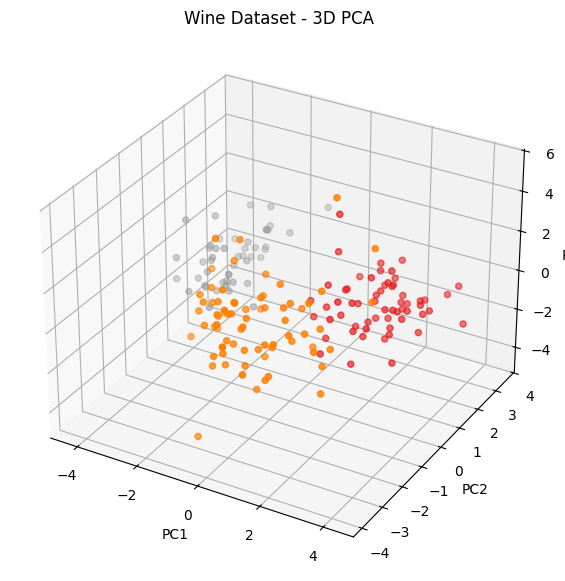

In [5]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y, cmap="Set1")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("Wine Dataset - 3D PCA")
plt.show()
